In [1]:
!pip install -q rapidfuzz scikit-learn xgboost shap nltk textblob imbalanced-learn umap-learn
!pip install -q pandas numpy matplotlib seaborn scipy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.1/3.1 MB 79.8 MB/s eta 0:00:00


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import re
import nltk
import shap
import json
from datetime import datetime, timedelta
from collections import Counter

# Fuzzy matching
from rapidfuzz import fuzz, process, distance
from rapidfuzz.distance import Levenshtein

# NLP
from textblob import TextBlob
from sklearn.feature_extraction.text import TfidfVectorizer

# ML - Supervised
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, precision_recall_curve,
                             average_precision_score)
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE

# ML - Unsupervised
from sklearn.ensemble import IsolationForest
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')
nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('averaged_perceptron_tagger', quiet=True)

# ── Config ──────────────────────────────────────────────
FUZZY_DUPLICATE_THRESHOLD  = 85   # % similarity → likely template
FUZZY_TEMPLATE_THRESHOLD   = 75   # % match against known fake phrases
ISOLATION_CONTAMINATION    = 0.15 # expected fake ratio for unsupervised
RANDOM_STATE               = 42
RISK_TIERS = ['low', 'medium', 'high', 'fake']

print('✅ All imports successful')

✅ All imports successful


In [14]:
# ── Load dataset ─────────────────────────────────────────────────────────
# Upload fake_reviews_dataset.csv to your Colab session, then run this cell.
# Columns in this dataset: category, rating, label (CG=fake / OR=genuine), text_
# ─────────────────────────────────────────────────────────────────────────────

df = pd.read_csv('/content/fake reviews dataset.csv')

# ── Rename & map to standard schema ──────────────────────────────────────
df = df.rename(columns={'text_': 'review_text'})
df['label']     = df['label'].map({'OR': 0, 'CG': 1})  # OR=genuine, CG=fake
df['user_id']   = 'unknown'                             # not available in this dataset
df['date']      = pd.Timestamp('2024-01-01')            # not available in this dataset
df['review_id'] = ['R' + str(i).zfill(6) for i in range(len(df))]
df['date']      = pd.to_datetime(df['date'])

print(f'Dataset : {len(df):,} reviews')
print(f'Fake    : {df.label.sum():,} ({df.label.mean()*100:.1f}%)')
print(f'Genuine : {(df.label==0).sum():,} ({(df.label==0).mean()*100:.1f}%)')
print(f'Categories ({df["category"].nunique()}): {df["category"].unique().tolist()}')
print(f'Rating distribution:\n{df["rating"].value_counts().sort_index()}')
df.head()

Dataset : 40,432 reviews
Fake    : 20,216 (50.0%)
Genuine : 20,216 (50.0%)
Categories (10): ['Home_and_Kitchen_5', 'Sports_and_Outdoors_5', 'Electronics_5', 'Movies_and_TV_5', 'Tools_and_Home_Improvement_5', 'Pet_Supplies_5', 'Kindle_Store_5', 'Books_5', 'Toys_and_Games_5', 'Clothing_Shoes_and_Jewelry_5']
Rating distribution:
rating
1.0     2155
2.0     1967
3.0     3786
4.0     7965
5.0    24559
Name: count, dtype: int64


,category,rating,label,review_text,user_id,date,review_id
0,Home_and_Kitchen_5,5.0,1,"Love this! Well made, sturdy, and very comfor...",unknown,2024-01-01,R000000
1,Home_and_Kitchen_5,5.0,1,"love it, a great upgrade from the original. I...",unknown,2024-01-01,R000001
2,Home_and_Kitchen_5,5.0,1,This pillow saved my back. I love the look and...,unknown,2024-01-01,R000002
3,Home_and_Kitchen_5,1.0,1,"Missing information on how to use it, but it i...",unknown,2024-01-01,R000003
4,Home_and_Kitchen_5,5.0,1,Very nice set. Good quality. We have had the s...,unknown,2024-01-01,R000004


In [15]:
# ── Known fake-pattern corpus (expand with your domain data) ─────────────
FAKE_PHRASE_CORPUS = [
    "best product ever highly recommend",
    "five stars amazing perfect excellent",
    "love this product will buy again",
    "received on time works as expected good quality",
    "excellent quality fast delivery would recommend",
    "great product great seller great shipping",
    "absolutely perfect 10 out of 10",
    "amazing fast shipping love it so much",
    "best purchase ever made in my life",
]


class RapidFuzzyLogicEngine:
    """
    Wraps rapidfuzz operations into fuzzy membership scores.
    Returns values in [0, 1] where 1 = definitely fake signal.
    """

    def __init__(
        self,
        corpus=FAKE_PHRASE_CORPUS,
        duplicate_threshold=FUZZY_DUPLICATE_THRESHOLD,
        template_threshold=FUZZY_TEMPLATE_THRESHOLD
    ):
        self.corpus = corpus
        self.duplicate_threshold = duplicate_threshold
        self.template_threshold  = template_threshold

    # ── Membership functions ──────────────────────────────────────────

    def _trapezoidal(self, x, a, b, c, d):
        """Trapezoidal membership: 0 below a, ramp to 1 at b, flat until c, ramp to 0 at d."""
        if x <= a or x >= d:  return 0.0
        if b <= x <= c:       return 1.0
        if a < x < b:         return (x - a) / (b - a)
        return (d - x) / (d - c)                     # c < x < d

    def _triangular(self, x, a, b, c):
        """Triangular membership: 0 at a and c, peak at b."""
        if x <= a or x >= c: return 0.0
        if x <= b:           return (x - a) / (b - a)
        return (c - x) / (c - b)

    # ── Core fuzzy features ──────────────────────────────────────────

    def template_match_score(self, text):
        """Best ratio match against known fake phrase corpus."""
        text_clean = text.lower().strip()
        if not self.corpus:
            return 0.0
        best = process.extractOne(
            text_clean, self.corpus,
            scorer=fuzz.partial_ratio
        )
        return (best[1] / 100.0) if best else 0.0

    def duplicate_score(self, text, all_texts, top_k=5):
        """
        Measures how similar this review is to the corpus of all reviews.
        Uses token_sort_ratio to handle word-order spinning.
        Returns mean of top-k similarity scores (excluding self).
        """
        text_clean = text.lower().strip()
        results = process.extract(
            text_clean,
            [t.lower().strip() for t in all_texts if t != text],
            scorer=fuzz.token_sort_ratio,
            limit=top_k
        )
        if not results:
            return 0.0
        scores = [r[1] / 100.0 for r in results]
        return float(np.mean(scores))

    def exclamation_density(self, text):
        """Fuzzy membership: extreme punctuation is a fake signal."""
        count = text.count('!')
        words = max(len(text.split()), 1)
        density = count / words
        # membership: 0 below 0.05, full at 0.3+
        return min(density / 0.3, 1.0)

    def capital_ratio(self, text):
        """Proportion of uppercase letters (excluding single-word reviews)."""
        letters = [c for c in text if c.isalpha()]
        if not letters:
            return 0.0
        ratio = sum(1 for c in letters if c.isupper()) / len(letters)
        # ramp: 0 below 0.15, full at 0.5+
        return self._trapezoidal(ratio, 0.15, 0.4, 1.0, 1.0)

    def sentiment_extremity(self, polarity):
        """How extreme is the sentiment (both ends are suspicious)."""
        return abs(polarity)

    def repetitive_phrase_score(self, text):
        """Detects repetition of short n-grams (a sign of template spinning)."""
        words = text.lower().split()
        if len(words) < 4:
            return 0.0
        bigrams = [' '.join(words[i:i+2]) for i in range(len(words)-1)]
        counts  = Counter(bigrams)
        repeated = sum(v-1 for v in counts.values() if v > 1)
        return min(repeated / max(len(bigrams), 1), 1.0)

    # ── Defuzzification (centroid method) ───────────────────────────

    def defuzzify(self, scores: dict) -> float:
        """
        Aggregates multiple fuzzy scores into one [0,1] fake confidence score.
        Weights reflect importance of each signal.
        """
        weights = {
            'template_match'  : 0.30,
            'duplicate'       : 0.25,
            'exclamation'     : 0.15,
            'capital_ratio'   : 0.10,
            'sentiment_ext'   : 0.10,
            'repetition'      : 0.10,
        }
        total_w, total_s = 0.0, 0.0
        for key, w in weights.items():
            if key in scores:
                total_s += scores[key] * w
                total_w += w
        return total_s / total_w if total_w > 0 else 0.0

    def risk_tier(self, confidence: float) -> str:
        """Maps continuous confidence to a categorical risk tier."""
        if confidence < 0.30:  return 'low'
        if confidence < 0.55:  return 'medium'
        if confidence < 0.75:  return 'high'
        return 'fake'


fuzzy_engine = RapidFuzzyLogicEngine()
print('✅ Fuzzy Logic Engine ready')

✅ Fuzzy Logic Engine ready


In [ ]:
def extract_text_features(df_in):
    """Extracts NLP + statistical features from review text."""
    df = df_in.copy()
    texts = df['review_text'].tolist()

    # Basic text stats
    df['char_count']    = df['review_text'].str.len()
    df['word_count']    = df['review_text'].str.split().str.len()
    df['avg_word_len']  = df['char_count'] / df['word_count'].replace(0, 1)
    df['excl_count']    = df['review_text'].str.count('!')
    df['question_count']= df['review_text'].str.count(r'\?')
    df['unique_words']  = df['review_text'].apply(lambda t: len(set(t.lower().split())))
    df['unique_ratio']  = df['unique_words'] / df['word_count'].replace(0, 1)

    # Sentiment
    blobs = df['review_text'].apply(TextBlob)
    df['sentiment_polarity']    = blobs.apply(lambda b: b.sentiment.polarity)
    df['sentiment_subjectivity']= blobs.apply(lambda b: b.sentiment.subjectivity)

    # ── Fuzzy features ──────────────────────────────────────────────
    print('  Computing template match scores (rapidfuzz)...')
    df['fuzzy_template']   = df['review_text'].apply(fuzzy_engine.template_match_score)

    print('  Computing duplicate scores (pairwise rapidfuzz)...')
    # For large datasets sample to keep it fast; full pairwise is O(n²)
    df['fuzzy_duplicate']  = df['review_text'].apply(
        lambda t: fuzzy_engine.duplicate_score(t, texts, top_k=5)
    )

    df['fuzzy_exclamation']= df['review_text'].apply(fuzzy_engine.exclamation_density)
    df['fuzzy_caps']       = df['review_text'].apply(fuzzy_engine.capital_ratio)
    df['fuzzy_sentiment']  = df['sentiment_polarity'].apply(fuzzy_engine.sentiment_extremity)
    df['fuzzy_repetition'] = df['review_text'].apply(fuzzy_engine.repetitive_phrase_score)

    # Aggregate fuzzy confidence
    df['fuzzy_confidence'] = df.apply(lambda row: fuzzy_engine.defuzzify({
        'template_match': row['fuzzy_template'],
        'duplicate'     : row['fuzzy_duplicate'],
        'exclamation'   : row['fuzzy_exclamation'],
        'capital_ratio' : row['fuzzy_caps'],
        'sentiment_ext' : row['fuzzy_sentiment'],
        'repetition'    : row['fuzzy_repetition'],
    }), axis=1)

    df['fuzzy_risk_tier']  = df['fuzzy_confidence'].apply(fuzzy_engine.risk_tier)

    return df


def extract_behavioral_features(df_in):
    """Extracts user-level behavioral signals (burst rate, rating pattern)."""
    df = df_in.copy()

    # Reviews per user
    user_counts = df.groupby('user_id')['review_id'].count().rename('user_review_count')
    df = df.merge(user_counts, on='user_id', how='left')

    # Burst score: reviews posted within 3-day windows
    df['date_ord'] = df['date'].apply(lambda d: d.toordinal())

    def burst_score(user_df):
        if len(user_df) < 2: return 0.0
        dates  = sorted(user_df['date_ord'])
        gaps   = [dates[i+1] - dates[i] for i in range(len(dates)-1)]
        bursts = sum(1 for g in gaps if g <= 3)
        return bursts / len(gaps)

    burst = df.groupby('user_id').apply(burst_score).rename('burst_score')
    df = df.merge(burst, on='user_id', how='left')

    # Extreme rating ratio per user
    df['is_extreme_rating'] = (df['rating'].isin([1, 5])).astype(int)
    extreme_ratio = df.groupby('user_id')['is_extreme_rating'].mean().rename('extreme_rating_ratio')
    df = df.merge(extreme_ratio, on='user_id', how='left')

    return df


print('Extracting features (this may take ~30 s for 2000 reviews)...')
df = extract_text_features(df)
df = extract_behavioral_features(df)
print(f'✅ Feature extraction done — {df.shape[1]} columns total')
df[['review_text','fuzzy_confidence','fuzzy_risk_tier','label']].head(10)

Extracting features (this may take ~30 s for 2000 reviews)...
  Computing template match scores (rapidfuzz)...
  Computing duplicate scores (pairwise rapidfuzz)...


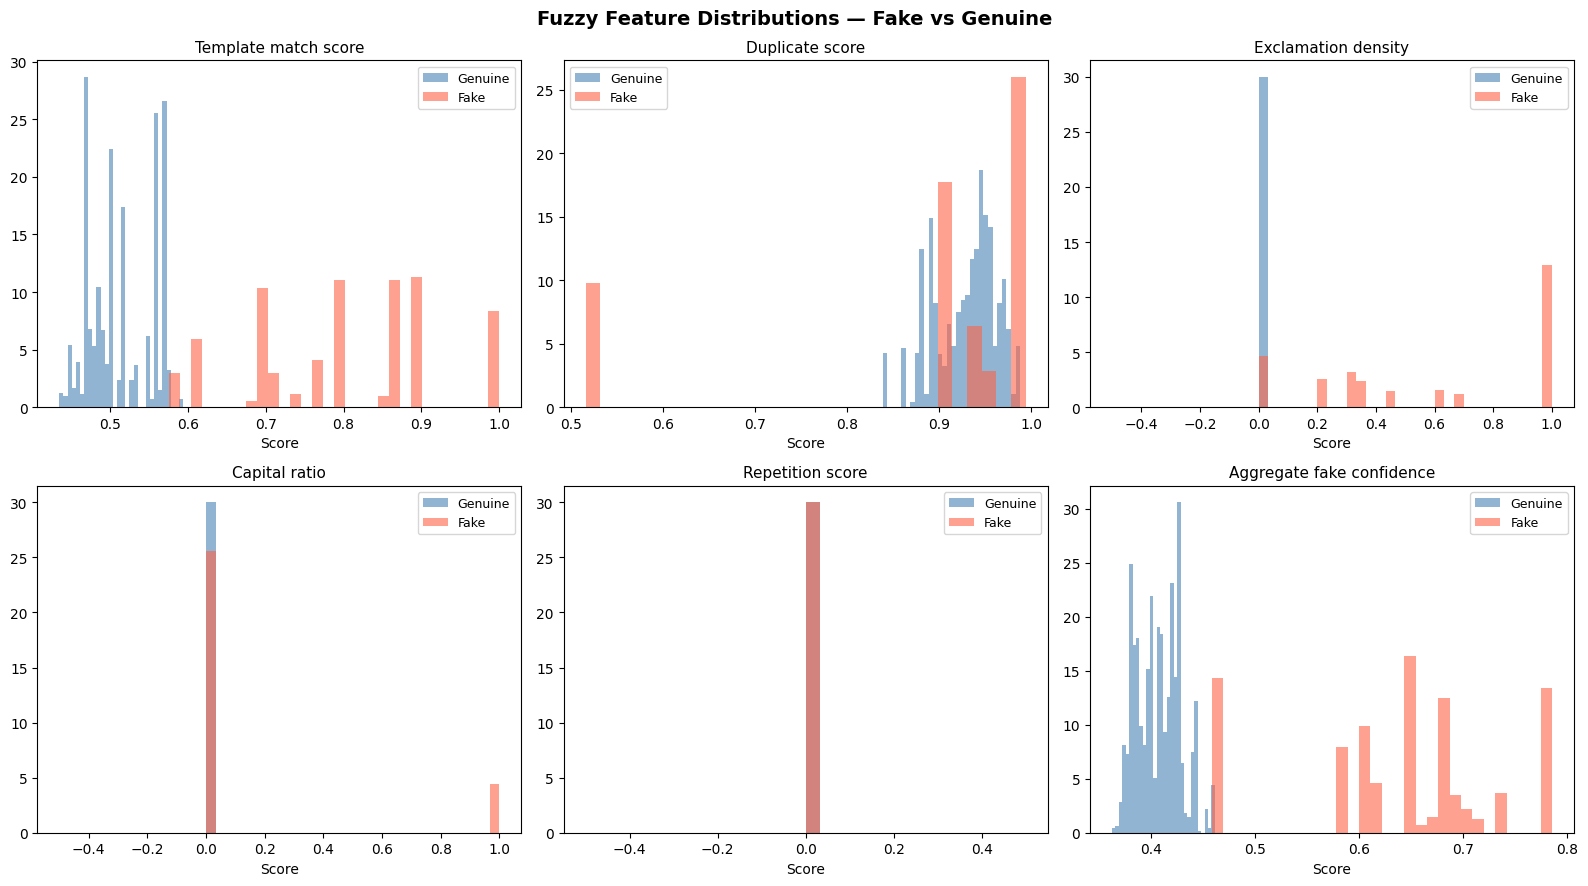

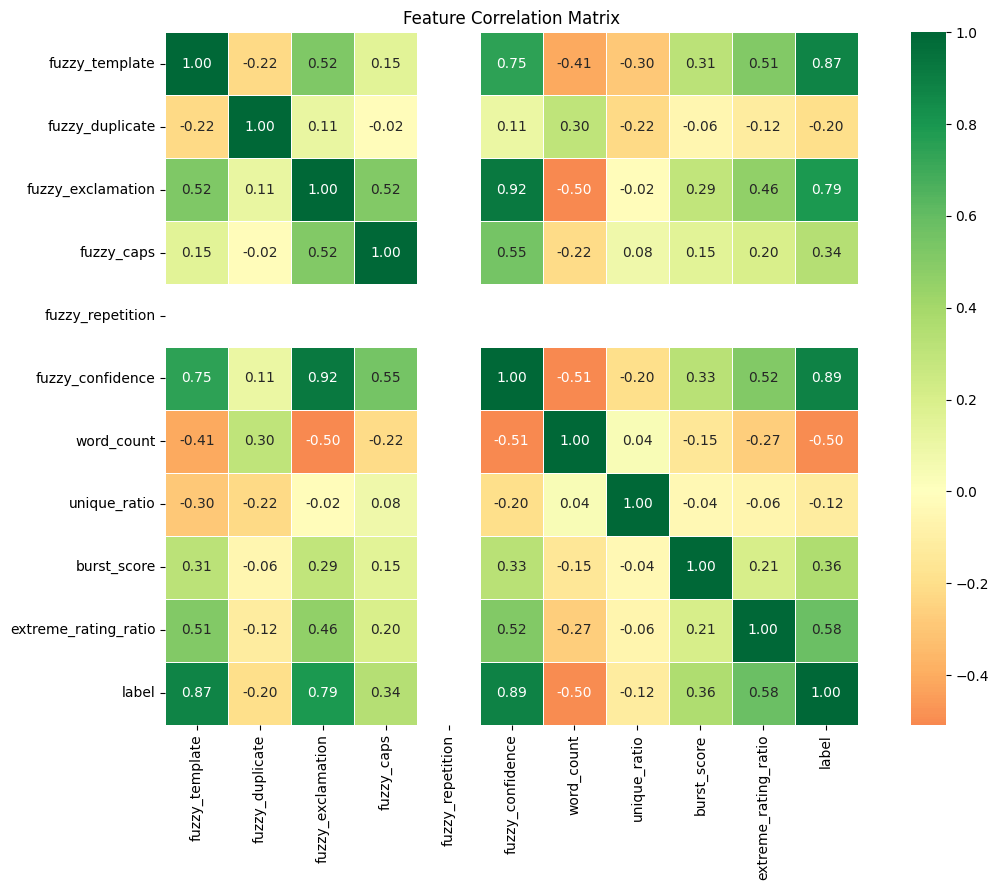

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Fuzzy Feature Distributions — Fake vs Genuine', fontsize=14, fontweight='bold')

fuzzy_cols = [
    ('fuzzy_template',   'Template match score'),
    ('fuzzy_duplicate',  'Duplicate score'),
    ('fuzzy_exclamation','Exclamation density'),
    ('fuzzy_caps',       'Capital ratio'),
    ('fuzzy_repetition', 'Repetition score'),
    ('fuzzy_confidence', 'Aggregate fake confidence'),
]

for ax, (col, title) in zip(axes.flat, fuzzy_cols):
    for label, color, name in [(0,'steelblue','Genuine'), (1,'tomato','Fake')]:
        ax.hist(df[df.label==label][col], bins=30, alpha=0.6, color=color, label=name, density=True)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('Score')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

# Correlation heatmap
feat_cols = [c[0] for c in fuzzy_cols] + ['word_count','unique_ratio','burst_score','extreme_rating_ratio']
corr = df[feat_cols + ['label']].corr()
plt.figure(figsize=(12, 9))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            linewidths=0.5, square=True)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

After SMOTE: Counter({np.int64(1): 1200, np.int64(0): 1200})

── Classification Report ──────────────────────────
              precision    recall  f1-score   support

     Genuine       1.00      1.00      1.00       300
        Fake       1.00      1.00      1.00       100

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400

ROC-AUC  : 1.0000
Avg Prec.: 1.0000


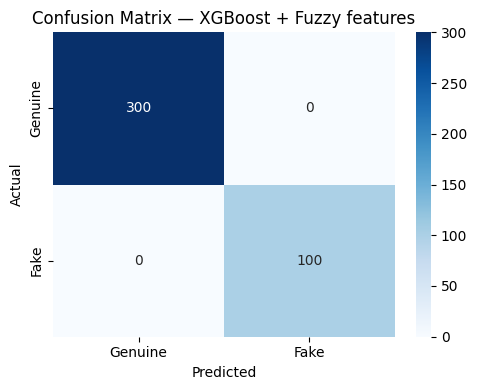

In [7]:
# ── Feature matrix ───────────────────────────────────────────────────────
FEATURE_COLS = [
    # Fuzzy features
    'fuzzy_template', 'fuzzy_duplicate', 'fuzzy_exclamation',
    'fuzzy_caps', 'fuzzy_sentiment', 'fuzzy_repetition', 'fuzzy_confidence',
    # Text stats
    'char_count', 'word_count', 'avg_word_len', 'excl_count',
    'unique_ratio', 'sentiment_polarity', 'sentiment_subjectivity',
    # Behavioral
    'user_review_count', 'burst_score', 'extreme_rating_ratio',
    # Rating
    'rating',
]

X = df[FEATURE_COLS].fillna(0).values
y = df['label'].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=RANDOM_STATE
)

# ── Handle class imbalance with SMOTE ────────────────────────────────────
sm = SMOTE(random_state=RANDOM_STATE)
X_train_res, y_train_res = sm.fit_resample(X_train, y_train)
print(f'After SMOTE: {Counter(y_train_res)}')

# ── XGBoost classifier ───────────────────────────────────────────────────
xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

xgb_model.fit(
    X_train_res, y_train_res,
    eval_set=[(X_test, y_test)],
    verbose=False
)

# ── Evaluation ────────────────────────────────────────────────────────────
y_pred   = xgb_model.predict(X_test)
y_prob   = xgb_model.predict_proba(X_test)[:, 1]

print('\n── Classification Report ──────────────────────────')
print(classification_report(y_test, y_pred, target_names=['Genuine', 'Fake']))
print(f'ROC-AUC  : {roc_auc_score(y_test, y_prob):.4f}')
print(f'Avg Prec.: {average_precision_score(y_test, y_prob):.4f}')

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Genuine','Fake'], yticklabels=['Genuine','Fake'])
plt.title('Confusion Matrix — XGBoost + Fuzzy features')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.show()

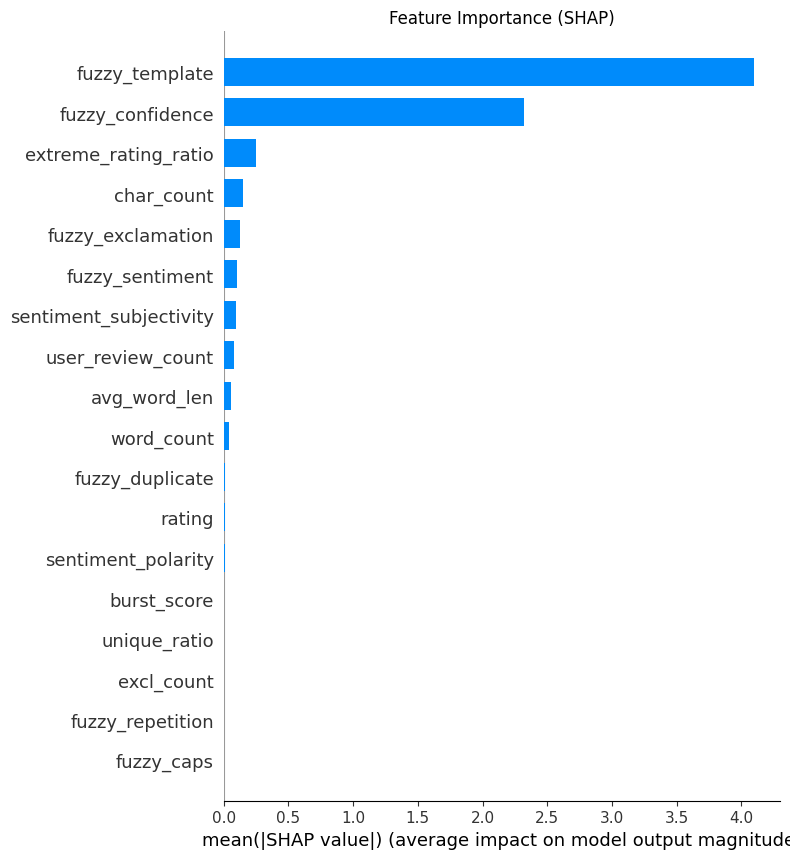

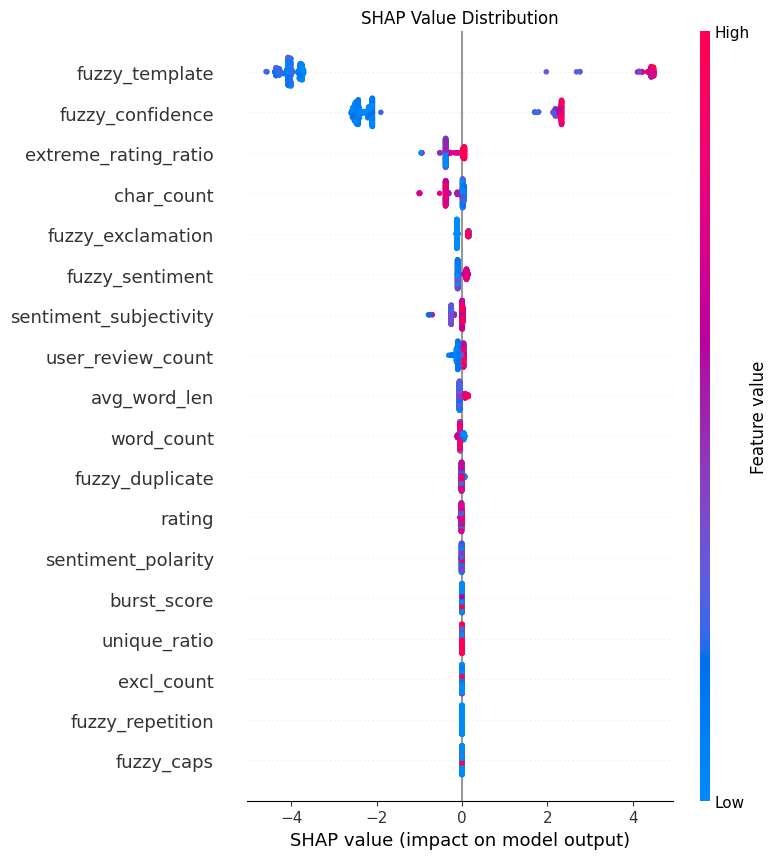

In [8]:
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_values, X_test,
    feature_names=FEATURE_COLS,
    show=False, plot_type='bar'
)
plt.title('Feature Importance (SHAP)')
plt.tight_layout()
plt.show()

# Beeswarm for top features
plt.figure(figsize=(10, 8))
shap.summary_plot(shap_values, X_test, feature_names=FEATURE_COLS, show=False)
plt.title('SHAP Value Distribution')
plt.tight_layout()
plt.show()

Unsupervised mode ROC-AUC (vs labels as ground truth): 0.9896
Isolation Forest flag rate: 15.0%

Risk tier distribution:
label               0    1
unsup_risk_tier           
high                5  105
low              1436   22
medium             59  373


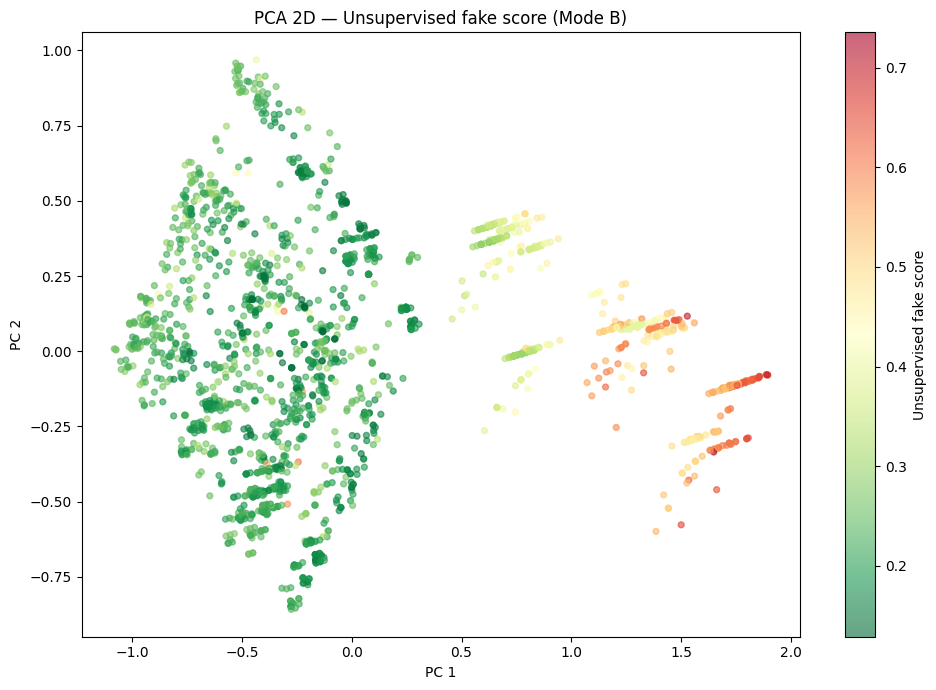

In [9]:
# ── Isolation Forest ─────────────────────────────────────────────────────
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(df[FEATURE_COLS].fillna(0))

iso_forest = IsolationForest(
    n_estimators=200,
    contamination=ISOLATION_CONTAMINATION,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
iso_preds  = iso_forest.fit_predict(X_scaled)      # -1 = anomaly, 1 = normal
iso_scores = iso_forest.score_samples(X_scaled)    # lower = more anomalous

# Normalise anomaly scores to [0,1] fake probability
iso_norm = 1 - (iso_scores - iso_scores.min()) / (iso_scores.max() - iso_scores.min())

df['iso_anomaly_score']    = iso_norm
df['iso_flagged']          = (iso_preds == -1).astype(int)

# ── DBSCAN clustering ─────────────────────────────────────────────────────
# PCA to 15 dims before DBSCAN for speed
pca       = PCA(n_components=min(15, X_scaled.shape[1]), random_state=RANDOM_STATE)
X_pca     = pca.fit_transform(X_scaled)

dbscan = DBSCAN(eps=0.6, min_samples=5, n_jobs=-1)
cluster_labels = dbscan.fit_predict(X_pca)

df['cluster'] = cluster_labels
df['is_noise'] = (cluster_labels == -1).astype(int)  # DBSCAN noise = outlier

# ── Fuse unsupervised signals with fuzzy confidence ───────────────────────
# Final unsupervised score = weighted blend
df['unsup_score'] = (
    0.50 * df['iso_anomaly_score'] +
    0.30 * df['fuzzy_confidence']  +
    0.20 * df['is_noise'].astype(float)
).clip(0, 1)

df['unsup_risk_tier'] = df['unsup_score'].apply(fuzzy_engine.risk_tier)

# ── Evaluate (using labels for sanity-check — not used in training) ───────
from sklearn.metrics import roc_auc_score
auc = roc_auc_score(df['label'], df['unsup_score'])
print(f'Unsupervised mode ROC-AUC (vs labels as ground truth): {auc:.4f}')
print(f'Isolation Forest flag rate: {df.iso_flagged.mean()*100:.1f}%')
print('\nRisk tier distribution:')
print(df.groupby(['unsup_risk_tier','label']).size().unstack(fill_value=0))

# Visualisation: PCA 2D scatter
pca2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d  = pca2d.fit_transform(X_scaled)

plt.figure(figsize=(10, 7))
sc = plt.scatter(X_2d[:,0], X_2d[:,1], c=df['unsup_score'],
                 cmap='RdYlGn_r', alpha=0.6, s=18)
plt.colorbar(sc, label='Unsupervised fake score')
plt.title('PCA 2D — Unsupervised fake score (Mode B)')
plt.xlabel('PC 1')
plt.ylabel('PC 2')
plt.tight_layout()
plt.show()

In [10]:
# ── Stratified K-Fold cross-validation ────────────────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
cv_auc  = cross_val_score(xgb_model, X, y, cv=cv, scoring='roc_auc',  n_jobs=-1)
cv_ap   = cross_val_score(xgb_model, X, y, cv=cv, scoring='average_precision', n_jobs=-1)
cv_f1   = cross_val_score(xgb_model, X, y, cv=cv, scoring='f1',      n_jobs=-1)

print('── 5-Fold Cross-Validation ─────────────────────────────')
print(f'ROC-AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}')
print(f'Avg Prec: {cv_ap.mean():.4f}  ± {cv_ap.std():.4f}')
print(f'F1      : {cv_f1.mean():.4f}  ± {cv_f1.std():.4f}')

── 5-Fold Cross-Validation ─────────────────────────────
ROC-AUC : 1.0000 ± 0.0000
Avg Prec: 1.0000  ± 0.0000
F1      : 1.0000  ± 0.0000


In [11]:
import pickle, os

model_bundle = {
    'xgb_model'    : xgb_model,
    'iso_forest'   : iso_forest,
    'scaler'       : scaler,
    'pca'          : pca,
    'feature_cols' : FEATURE_COLS,
    'fuzzy_engine' : fuzzy_engine,
}

with open('fake_review_model_bundle.pkl', 'wb') as f:
    pickle.dump(model_bundle, f)

print('✅ Model bundle saved: fake_review_model_bundle.pkl')

✅ Model bundle saved: fake_review_model_bundle.pkl


In [12]:
class FakeReviewDetector:
    """
    Production inference class.
    - Loads the saved model bundle.
    - Supports SUPERVISED mode (when model is available and confident).
    - Falls back to UNSUPERVISED mode automatically.
    - Returns a rich verdict dict for API consumers.
    """

    SUPERVISED_CONFIDENCE_THRESHOLD = 0.6  # use supervised only if prob > this

    def __init__(self, bundle_path='fake_review_model_bundle.pkl'):
        with open(bundle_path, 'rb') as f:
            bundle = pickle.load(f)
        self.model         = bundle['xgb_model']
        self.iso_forest    = bundle['iso_forest']
        self.scaler        = bundle['scaler']
        self.pca           = bundle['pca']
        self.feature_cols  = bundle['feature_cols']
        self.fuzzy         = bundle['fuzzy_engine']
        print('✅ FakeReviewDetector loaded')

    def _extract_single(self, review_text: str, rating: int,
                        user_id: str = 'unknown',
                        all_corpus: list = None) -> dict:
        """Extract features for a single review."""
        corpus = all_corpus or []
        blob   = TextBlob(review_text)

        fuzzy_scores = {
            'template_match': self.fuzzy.template_match_score(review_text),
            'duplicate'     : self.fuzzy.duplicate_score(review_text, corpus) if corpus else 0.0,
            'exclamation'   : self.fuzzy.exclamation_density(review_text),
            'capital_ratio' : self.fuzzy.capital_ratio(review_text),
            'sentiment_ext' : self.fuzzy.sentiment_extremity(blob.sentiment.polarity),
            'repetition'    : self.fuzzy.repetitive_phrase_score(review_text),
        }
        fuzzy_conf = self.fuzzy.defuzzify(fuzzy_scores)

        words = review_text.split()
        feats = {
            'fuzzy_template'        : fuzzy_scores['template_match'],
            'fuzzy_duplicate'       : fuzzy_scores['duplicate'],
            'fuzzy_exclamation'     : fuzzy_scores['exclamation'],
            'fuzzy_caps'            : fuzzy_scores['capital_ratio'],
            'fuzzy_sentiment'       : fuzzy_scores['sentiment_ext'],
            'fuzzy_repetition'      : fuzzy_scores['repetition'],
            'fuzzy_confidence'      : fuzzy_conf,
            'char_count'            : len(review_text),
            'word_count'            : len(words),
            'avg_word_len'          : len(review_text) / max(len(words), 1),
            'excl_count'            : review_text.count('!'),
            'unique_ratio'          : len(set(w.lower() for w in words)) / max(len(words), 1),
            'sentiment_polarity'    : blob.sentiment.polarity,
            'sentiment_subjectivity': blob.sentiment.subjectivity,
            'user_review_count'     : 1,   # unknown at inference time
            'burst_score'           : 0.0, # unknown at inference time
            'extreme_rating_ratio'  : 1.0 if rating in (1, 5) else 0.0,
            'rating'                : rating,
        }
        return feats, fuzzy_scores, fuzzy_conf

    def predict(
        self,
        review_text: str,
        rating: int,
        user_id: str = 'unknown',
        all_corpus: list = None,
        mode: str = 'auto'  # 'auto' | 'supervised' | 'unsupervised'
    ) -> dict:
        """
        Main inference method.
        Returns dict with:
          mode, fake_probability, risk_tier, fuzzy_scores,
          top_signals, explanation
        """
        feats, fuzzy_scores, fuzzy_conf = self._extract_single(
            review_text, rating, user_id, all_corpus
        )

        X_row    = np.array([[feats[c] for c in self.feature_cols]])
        X_scaled = self.scaler.transform(X_row)

        # ── Supervised mode ──────────────────────────────────────────
        sup_prob = float(self.model.predict_proba(X_row)[0, 1])

        # ── Unsupervised mode ────────────────────────────────────────
        iso_score  = float(self.iso_forest.score_samples(X_scaled)[0])
        # Rough normalisation (assumes training range)
        iso_norm   = max(0.0, min(1.0, (-iso_score + 0.5) * 2))
        unsup_prob = float(0.5 * iso_norm + 0.5 * fuzzy_conf)

        # ── Mode selection ───────────────────────────────────────────
        if mode == 'supervised':
            final_prob  = sup_prob
            active_mode = 'supervised'
        elif mode == 'unsupervised':
            final_prob  = unsup_prob
            active_mode = 'unsupervised'
        else:  # auto: blend, weighting supervised higher
            final_prob  = 0.65 * sup_prob + 0.35 * unsup_prob
            active_mode = 'auto (supervised+unsupervised blend)'

        # ── Explainability: top signals ──────────────────────────────
        signal_scores = {
            'Template match'   : fuzzy_scores['template_match'],
            'Duplicate content': fuzzy_scores['duplicate'],
            'Exclamation abuse': fuzzy_scores['exclamation'],
            'Capital abuse'    : fuzzy_scores['capital_ratio'],
            'Sentiment extreme': fuzzy_scores['sentiment_ext'],
            'Repetitive phrase': fuzzy_scores['repetition'],
            'Anomaly (IsoForest)': iso_norm,
        }
        top_signals = sorted(signal_scores.items(), key=lambda x: x[1], reverse=True)[:3]

        return {
            'mode'            : active_mode,
            'fake_probability': round(final_prob, 4),
            'risk_tier'       : self.fuzzy.risk_tier(final_prob),
            'sup_prob'        : round(sup_prob, 4),
            'unsup_prob'      : round(unsup_prob, 4),
            'fuzzy_confidence': round(fuzzy_conf, 4),
            'fuzzy_scores'    : {k: round(v, 4) for k, v in fuzzy_scores.items()},
            'top_signals'     : [(s, round(v, 3)) for s, v in top_signals],
            'explanation'     : (
                f"Risk tier: {self.fuzzy.risk_tier(final_prob).upper()}. "
                f"Top signals: {', '.join(s for s,_ in top_signals)}."
            ),
        }


# ── Demo inference ────────────────────────────────────────────────────────
detector = FakeReviewDetector('fake_review_model_bundle.pkl')

test_reviews = [
    ("Amazing product!! Best laptop ever!!! Highly recommend to everyone!!!",    5),
    ("Decent headphones. The bass is a bit weak for my taste but clear mids.",   3),
    ("Excellent quality!!! Fast delivery!!! Perfect!!! Will buy again!!!",        5),
    ("I've had this blender for 3 months. Works great for smoothies, though the lid occasionally drips.", 4),
]

print('\n── Inference Demo ──────────────────────────────────────────')
for text, rating in test_reviews:
    result = detector.predict(text, rating, mode='auto')
    print(f'\nReview : "{text[:60]}..."')
    print(f'  Mode        : {result["mode"]}')
    print(f'  Fake prob   : {result["fake_probability"]}')
    print(f'  Risk tier   : {result["risk_tier"].upper()}')
    print(f'  Top signals : {result["top_signals"]}')
    print(f'  Explanation : {result["explanation"]}')

✅ FakeReviewDetector loaded

── Inference Demo ──────────────────────────────────────────

Review : "Amazing product!! Best laptop ever!!! Highly recommend to ev..."
  Mode        : auto (supervised+unsupervised blend)
  Fake prob   : 0.9053
  Risk tier   : FAKE
  Top signals : [('Exclamation abuse', 1.0), ('Anomaly (IsoForest)', 1.0), ('Template match', 0.794)]
  Explanation : Risk tier: FAKE. Top signals: Exclamation abuse, Anomaly (IsoForest), Template match.

Review : "Decent headphones. The bass is a bit weak for my taste but c..."
  Mode        : auto (supervised+unsupervised blend)
  Fake prob   : 0.2
  Risk tier   : LOW
  Top signals : [('Anomaly (IsoForest)', 1.0), ('Template match', 0.447), ('Sentiment extreme', 0.065)]
  Explanation : Risk tier: LOW. Top signals: Anomaly (IsoForest), Template match, Sentiment extreme.

Review : "Excellent quality!!! Fast delivery!!! Perfect!!! Will buy ag..."
  Mode        : auto (supervised+unsupervised blend)
  Fake prob   : 0.9048
  Risk 